# ⚽ Football Score Prediction Yooji vs Beeta
## Menyelamatkan Mina dengan Machine Learning

> *"Nyawa Mina berada di ujung jariku. Aku harus memenangkan permainan hidup-mati ini sebelum peluit akhir dibunyikan."*

Notebook ini menyajikan pipeline lengkap untuk memprediksi **skor pertandingan sepak bola internasional** menggunakan pendekatan ensemble tiga model gradient boosting.

### Gambaran Masalah
- **Data historis**: Pertandingan sepak bola internasional 1872-2011
- **Target prediksi**: Skor pertandingan 2011–2026 (`team_goals` dan `opp_goals`)
- **Metrik evaluasi**: Augmented Weighted Mean Absolute Error (AW-MAE)
- **Tantangan utama**: Metrik non-linear dengan penalti berlapis (exact score, outcome, goal difference)

### Pendekatan
Digunakan **ensemble tiga model komplementer** dengan objective Poisson (cocok untuk count data seperti gol):

| Model | Peran |
|---|---|
| **LightGBM** | Cepat, efisien memori, performa kuat pada tabular data |
| **XGBoost** | Regularisasi kuat, sering unggul di kompetisi ML |
| **CatBoost** | Robust terhadap outlier, tidak butuh banyak tuning |

Bobot ensemble dihitung otomatis dari **inverse AW-MAE di validation set** model yang lebih akurat mendapat bobot lebih besar.

## Cell 1
## Instalasi dan Import Library

### Library yang Digunakan

| Library | Fungsi |
|---|---|
| `lightgbm` | Model gradient boosting dengan Poisson objective |
| `xgboost` | Model gradient boosting dengan count:poisson objective |
| `catboost` | Model gradient boosting dengan Poisson loss |
| `pandas`, `numpy` | Manipulasi data dan komputasi numerik |
| `sklearn` | Train/val split dan metrik evaluasi |
| `matplotlib`, `seaborn` | Visualisasi hasil dan distribusi |

Semua library diinstall secara otomatis jika belum tersedia di environment.

In [1]:
# INSTALASI DAN IMPORT LIBRARY

import subprocess, sys
for pkg in ['lightgbm', 'xgboost', 'catboost']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('husl')

from catboost import __version__ as cb_ver
print(f'LightGBM  : {lgb.__version__}')
print(f'XGBoost   : {xgb.__version__}')
print(f'CatBoost  : {cb_ver}')
print(f'Pandas    : {pd.__version__}')
print(f'NumPy     : {np.__version__}')
print('Libraries loaded successfully!')


LightGBM  : 4.6.0
XGBoost   : 3.2.0
CatBoost  : 1.2.10
Pandas    : 2.3.3
NumPy     : 2.0.2
Libraries loaded successfully!


## Cell 2
## Load Data dan Eksplorasi Awal

### Sumber Data
Tiga file CSV digunakan dalam pipeline ini:
- **train.csv** = Data historis pertandingan 1872-2011, berisi skor aktual sebagai target
- **test.csv** = Data pertandingan 2011-2026 yang harus diprediksi skornya
- **sample submission.csv** = Format submission yang diharapkan kompetisi

### Struktur Data
Setiap baris merepresentasikan **satu perspektif tim** dalam satu pertandingan. Artinya setiap pertandingan menghasilkan **dua baris**, satu dari perspektif tim, satu dari perspektif lawan. Ini penting untuk post-processing konsistensi di akhir pipeline.

In [2]:

train      = pd.read_csv('/kaggle/input/competitions/deescuy/train.csv')
test       = pd.read_csv('/kaggle/input/competitions/deescuy/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/deescuy/sample submission.csv')

train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

print(f'Train : {train.shape}  |  {train["date"].min().date()} -> {train["date"].max().date()}')
print(f'Test  : {test.shape}   |  {test["date"].min().date()} -> {test["date"].max().date()}')
print(f'\nKolom train: {train.columns.tolist()}')
print(f'Kolom test : {test.columns.tolist()}')
train.head(3)


Train : (78772, 47)  |  1872-11-30 -> 2011-08-04
Test  : (42422, 20)   |  2011-08-06 -> 2026-03-31

Kolom train: ['Id', 'match_id', 'date', 'gender', 'team', 'opponent', 'is_home', 'neutral', 'tournament', 'venue_country', 'team_goals', 'opp_goals', 'team_points_last5', 'opp_points_last5', 'points_last5_diff', 'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff', 'h2h_points_last5', 'h2h_gd_last5', 'days_since_last_match_team', 'days_since_last_match_opp', 'team_points_last10', 'opp_points_last10', 'team_avg_goals_last5', 'team_avg_conceded_last5', 'opp_avg_goals_last5', 'opp_avg_conceded_last5', 'team_win_rate_last10', 'opp_win_rate_last10', 'elo_team', 'elo_opponent', 'rank_team', 'rank_opponent', 'rank_diff', 'rank_missing_team', 'rank_missing_opp', 'confederation_team', 'confederation_opp', 'population_team', 'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'altitude_venue', 'distance_travel_team', 'distance_travel_opp', 'temperature_venue']
Kolom test : ['Id', 'match_id'

,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,...,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Statistik Target (train):
       team_goals  opp_goals
count   78772.000  78772.000
mean        1.563      1.563
std         1.792      1.792
min         0.000      0.000
25%         0.000      0.000
50%         1.000      1.000
75%         2.000      2.000
max        31.000     31.000


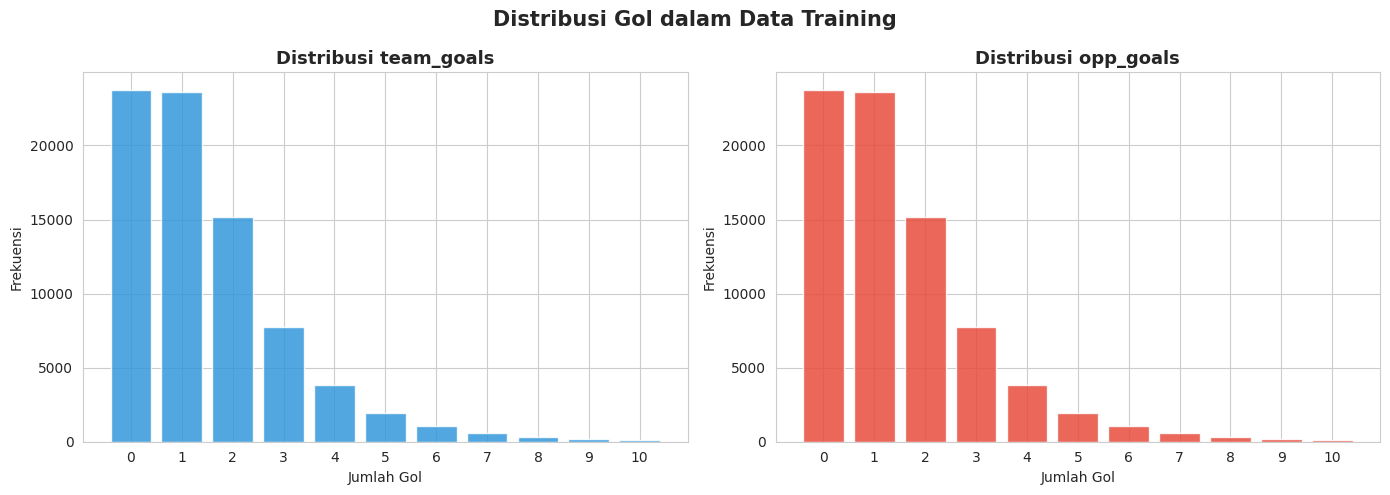

Rata-rata gol per pertandingan (team): 1.563


In [3]:
# STATISTIK DESKRIPTIF TARGET

print('Statistik Target (train):')
print(train[['team_goals', 'opp_goals']].describe().round(3))

# Distribusi gol
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, c in zip(axes, ['team_goals','opp_goals'], ['#3498db','#e74c3c']):
    counts = train[col].value_counts().sort_index().loc[lambda x: x.index <= 10]
    ax.bar(counts.index, counts.values, color=c, alpha=0.85, edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Jumlah Gol'); ax.set_ylabel('Frekuensi')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.suptitle('Distribusi Gol dalam Data Training', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Rata-rata gol per pertandingan (team): {train["team_goals"].mean():.3f}')


## Cell 3
## Metrik Evaluasi: AW-MAE

### Definisi
Kompetisi menggunakan **Augmented Weighted Mean Absolute Error (AW-MAE)**, metrik non-linear yang lebih ketat dari MAE biasa:

$$\\text{AW-MAE} = \\frac{\\sum (\\text{Loss}_i \\times w_i)}{\\sum w_i}$$

### Komponen Penalti

| Komponen | Penalti | Keterangan |
|---|---|---|
| Base MAE | - | Rata-rata selisih absolut skor |
| Exact Score | +0.30 | Jika skor tidak tepat persis |
| Outcome (W/D/L) | +0.25 | Jika hasil akhir salah |
| Goal Difference | +0.15 | Jika selisih gol salah |
| Outcome Multiplier | ×1.5 | Pengali jika outcome salah |
| Non-linear | ^1.5 | Loss total dipangkatkan 1.5 |

### Bobot Turnamen
Pertandingan bergengsi mendapat bobot lebih besar dalam rata-rata akhir:

| Turnamen | Bobot |
|---|---|
| FIFA World Cup | 2.00 |
| UEFA Euro, Copa America, AFC Asian Cup, dll | 1.80 |
| FIFA WC Qualification | 1.60 |
| Friendly | 0.96 |
| Lainnya | 1.20 |

### Mengapa Ini Lebih Sulit dari MAE Biasa?
Penalti berlapis berarti prediksi `2-1` untuk pertandingan aktual `0-0` jauh lebih mahal dari sekadar selisih skor, karena outcome (W vs D) juga salah, yang mengaktifkan multiplier ×1.5 dan penalty +0.25.

In [4]:
# IMPLEMENTASI METRIK AW-MAE

TOURNAMENT_WEIGHTS = {
    'FIFA World Cup': 2.00,
    'AFC Asian Cup': 1.80, 'UEFA Euro': 1.80,
    'Copa America': 1.80, 'African Cup of Nations': 1.80,
    'CONCACAF Gold Cup': 1.80,
    'FIFA World Cup qualification': 1.60,
    'UEFA Euro qualification': 1.40,
    'African Cup of Nations qualification': 1.40,
    'Friendly': 0.96,
}
DEFAULT_WEIGHT = 1.20

def get_outcome(tg, og):
    return 'W' if tg > og else ('L' if tg < og else 'D')

def awmae_loss(pt, po, tt, to, tournament=''):
    mae     = (abs(pt - tt) + abs(po - to)) / 2
    exact   = int(pt == tt and po == to)
    correct = int(get_outcome(pt, po) == get_outcome(tt, to))
    gd_ok   = int((pt - po) == (tt - to))
    penalty = 0.30*(1-exact) + 0.25*(1-correct) + 0.15*(1-gd_ok)
    mult    = 1.0 if correct else 1.5
    loss    = ((mae + penalty) * mult) ** 1.5
    weight  = TOURNAMENT_WEIGHTS.get(tournament, DEFAULT_WEIGHT)
    return loss, weight

def compute_awmae(df, pred_team_col, pred_opp_col,
                  true_team_col='team_goals', true_opp_col='opp_goals',
                  tournament_col='tournament'):
    losses, weights = [], []
    for _, row in df.iterrows():
        l, w = awmae_loss(
            row[pred_team_col], row[pred_opp_col],
            row[true_team_col], row[true_opp_col],
            row.get(tournament_col, '')
        )
        losses.append(l); weights.append(w)
    return np.sum(np.array(losses) * np.array(weights)) / np.sum(weights)

# DEMONSTRASI SKENARIO PENALTI
print(f"{'Skenario':<42} {'AW-MAE Loss':>12}")
print('-' * 56)
for name, pt, po, tt, to in [
    ('Perfect prediction (2-1 vs 2-1)',      2, 1, 2, 1),
    ('Outcome benar, skor salah (2-0 vs 3-1)', 2, 0, 3, 1),
    ('Outcome salah - prediksi seri (1-1 vs 2-1)', 1, 1, 2, 1),
    ('Sama sekali salah (0-0 vs 3-1)',        0, 0, 3, 1),
]:
    l, _ = awmae_loss(pt, po, tt, to, 'Friendly')
    print(f'  {name:<40} {l:>12.4f}   ({pt}-{po} vs {tt}-{to})')


Skenario                                    AW-MAE Loss
--------------------------------------------------------
  Perfect prediction (2-1 vs 2-1)                0.0000   (2-1 vs 2-1)
  Outcome benar, skor salah (2-0 vs 3-1)         1.4822   (2-0 vs 3-1)
  Outcome salah - prediksi seri (1-1 vs 2-1)       2.4150   (1-1 vs 2-1)
  Sama sekali salah (0-0 vs 3-1)                 8.1505   (0-0 vs 3-1)


## Cell 4
## Feature Engineering

### Tujuan
Mengubah data mentah pertandingan menjadi fitur numerik yang dapat dipelajari oleh model gradient boosting. Feature engineering dilakukan dalam dua tahap:

1. **Statistik tim agregat** = dihitung dari data training, lalu di-join ke setiap baris
2. **Fitur derivatif** = dihitung dari kombinasi statistik tim untuk menangkap kekuatan relatif

### Daftar Fitur (31 Fitur Total)

| Kelompok | Fitur | Deskripsi |
|---|---|---|
| Team Stats | `team_avg_goals`, `team_avg_conceded`, `team_n_matches`, `team_win_rate` | Statistik historis tim |
| Opp Stats | `opp_avg_goals`, `opp_avg_conceded`, `opp_n_matches`, `opp_win_rate` | Statistik historis lawan |
| Recent Form | `recent_attack`, `recent_defense`, `recent_opp_attack`, `recent_opp_defense` | Performa 3 tahun terakhir |
| Match Context | `is_home`, `neutral`, `year`, `month`, `gender_enc` | Konteks pertandingan |
| Strength | `attack_vs_defense`, `opp_attack_vs_def`, `relative_strength` | Kekuatan relatif |
| Socioeconomic | `log_gdp_team/opp`, `log_pop_team/opp`, `log_gdp_diff`, `log_pop_diff` | Faktor ekonomi-demografi |
| Geographic | `altitude_venue`, `distance_travel_team/opp`, `temperature_venue` | Faktor geografis |
| Confederation | `confederation_team_enc`, `confederation_opp_enc` | Konfederasi (encoded) |

### Catatan: Log Transformation
GDP dan populasi menggunakan `log1p` transformation karena distribusinya sangat right-skewed. Tanpa transformasi, nilai ekstrem negara besar (China, India) akan mendominasi dan membingungkan model.

In [5]:
# KOMPUTASI STATISTIK TIM DARI DATA TRAINING

team_stats = train.groupby('team').agg(
    team_avg_goals    = ('team_goals', 'mean'),
    team_avg_conceded = ('opp_goals',  'mean'),
    team_n_matches    = ('team_goals', 'count'),
).reset_index()

opp_stats = team_stats.rename(columns={
    'team':'opponent', 'team_avg_goals':'opp_avg_goals',
    'team_avg_conceded':'opp_avg_conceded', 'team_n_matches':'opp_n_matches'})

_w = train.copy()
_w['won'] = (_w['team_goals'] > _w['opp_goals']).astype(float)
win_rates = _w.groupby('team')['won'].mean().reset_index()
win_rates.columns = ['team','team_win_rate']
opp_win = win_rates.rename(columns={'team':'opponent','team_win_rate':'opp_win_rate'})

# Recent form — 3 tahun terakhir data training
cutoff = train['date'].max() - pd.DateOffset(years=3)
recent = train[train['date'] >= cutoff]
recent_stats = recent.groupby('team').agg(
    team_recent_goals    = ('team_goals','mean'),
    team_recent_conceded = ('opp_goals', 'mean'),
).reset_index()
recent_opp = recent_stats.rename(columns={
    'team':'opponent', 'team_recent_goals':'opp_recent_goals',
    'team_recent_conceded':'opp_recent_conceded'})

print(f'Tim unik (all-time)     : {len(team_stats)}')
print(f'Tim dengan data terkini : {len(recent_stats)}')

# Top 10 tim berdasarkan rata-rata gol
top10 = team_stats.merge(win_rates, on='team').sort_values('team_avg_goals', ascending=False).head(10)
print('\nTop 10 tim berdasarkan rata-rata gol:')
print(top10[['team','team_avg_goals','team_avg_conceded','team_win_rate']].to_string(index=False))


Tim unik (all-time)     : 294
Tim dengan data terkini : 251

Top 10 tim berdasarkan rata-rata gol:
                team  team_avg_goals  team_avg_conceded  team_win_rate
              Kosovo        7.000000           1.000000       1.000000
               Åland        5.263158           0.789474       0.842105
               Sápmi        5.076923           1.615385       0.538462
Prince Edward Island        3.250000           0.750000       0.750000
             Silesia        3.000000           2.125000       0.375000
            Asturias        3.000000           1.000000       1.000000
           Occitania        2.888889           1.500000       0.444444
             Gotland        2.818182           1.757576       0.454545
              Tahiti        2.791878           1.497462       0.553299
      Canary Islands        2.750000           0.750000       0.750000


In [6]:
# FEATURE BUILDER FUNCTION

FEATURES = [
    'is_home', 'neutral', 'year', 'month', 'gender_enc',
    'confederation_team_enc', 'confederation_opp_enc',
    'log_pop_team', 'log_pop_opp', 'log_gdp_team', 'log_gdp_opp',
    'log_gdp_diff', 'log_pop_diff',
    'altitude_venue', 'distance_travel_team', 'distance_travel_opp', 'temperature_venue',
    'team_avg_goals', 'team_avg_conceded', 'team_n_matches', 'team_win_rate',
    'opp_avg_goals', 'opp_avg_conceded', 'opp_n_matches', 'opp_win_rate',
    'attack_vs_defense', 'opp_attack_vs_def', 'relative_strength',
    'recent_attack', 'recent_opp_attack', 'recent_defense', 'recent_opp_defense',
]

def build_features(df):
    df = df.copy()
    df = df.merge(team_stats,   on='team',     how='left')
    df = df.merge(opp_stats,    on='opponent', how='left')
    df = df.merge(win_rates,    on='team',     how='left')
    df = df.merge(opp_win,      on='opponent', how='left')
    df = df.merge(recent_stats, on='team',     how='left')
    df = df.merge(recent_opp,   on='opponent', how='left')

    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month

    df['attack_vs_defense'] = df['team_avg_goals'] / (df['opp_avg_conceded'] + 0.1)
    df['opp_attack_vs_def'] = df['opp_avg_goals']  / (df['team_avg_conceded'] + 0.1)
    df['relative_strength'] = df['team_win_rate'].fillna(0.5) - df['opp_win_rate'].fillna(0.5)

    df['recent_attack']      = df['team_recent_goals'].fillna(df['team_avg_goals'])
    df['recent_opp_attack']  = df['opp_recent_goals'].fillna(df['opp_avg_goals'])
    df['recent_defense']     = df['team_recent_conceded'].fillna(df['team_avg_conceded'])
    df['recent_opp_defense'] = df['opp_recent_conceded'].fillna(df['opp_avg_conceded'])

    df['confederation_team_enc'] = pd.Categorical(df['confederation_team']).codes
    df['confederation_opp_enc']  = pd.Categorical(df['confederation_opp']).codes
    df['gender_enc'] = (df['gender'] == 'M').astype(int)

    df['log_pop_team'] = np.log1p(df['population_team'].fillna(50e6))
    df['log_pop_opp']  = np.log1p(df['population_opp'].fillna(50e6))
    df['log_gdp_team'] = np.log1p(df['gdp_per_capita_team'].fillna(10000))
    df['log_gdp_opp']  = np.log1p(df['gdp_per_capita_opp'].fillna(10000))
    df['log_gdp_diff'] = df['log_gdp_team'] - df['log_gdp_opp']
    df['log_pop_diff'] = df['log_pop_team'] - df['log_pop_opp']

    for col in ['altitude_venue','distance_travel_team','distance_travel_opp','temperature_venue']:
        med = df[col].median()
        df[col] = df[col].fillna(med if pd.notna(med) else 0)

    return df

# BUILD FEATURES
tr = build_features(train)
te = build_features(test)
X_train = tr[FEATURES].fillna(0)
X_test  = te[FEATURES].fillna(0)
y_team  = tr['team_goals']
y_opp   = tr['opp_goals']

print(f'Total fitur    : {len(FEATURES)}')
print(f'X_train shape  : {X_train.shape}')
print(f'X_test shape   : {X_test.shape}')


Total fitur    : 32
X_train shape  : (78772, 32)
X_test shape   : (42422, 32)


## Cell 5
## Train/Validation Split

### Tujuan
Menyisihkan 10% data training sebagai **validation set** untuk dua keperluan:
1. Mengevaluasi performa masing-masing model secara objektif
2. Menghitung bobot ensemble berdasarkan AW-MAE validation (bukan training)

### Mengapa Bukan Time-Based Split?
Berbeda dengan time series forecasting, data pertandingan sepak bola tidak memiliki dependensi temporal yang kuat pada level row, statistik tim dihitung agregat dari keseluruhan data. Random split dengan `random_state` tetap memberikan reprodusibilitas yang cukup untuk keperluan ini.

Jika ingin lebih strict, bisa menggunakan pertandingan setelah tahun tertentu sebagai validation set.

In [7]:
# TRAIN/VALIDATION SPLIT

X_tr, X_val, y_tr_tm, y_val_tm, y_tr_op, y_val_op = train_test_split(
    X_train, y_team, y_opp, test_size=0.1, random_state=42)

val_tournaments = tr.loc[X_val.index, 'tournament']

print(f'Train rows : {len(X_tr):,}')
print(f'Val rows   : {len(X_val):,}')
print(f'Test rows  : {len(X_test):,}')


Train rows : 70,894
Val rows   : 7,878
Test rows  : 42,422


## Cell 6
## Konfigurasi dan Training Model Ensemble

### Mengapa Tiga Model?
Setiap model memiliki karakteristik berbeda dalam menangani data:

| Model | Objective | Kelebihan |
|---|---|---|
| **LightGBM** | `poisson` | Leaf-wise growth, sangat cepat, efisien memori |
| **XGBoost** | `count:poisson` | Level-wise growth, regularisasi L1/L2 kuat |
| **CatBoost** | `Poisson` | Symmetric trees, robust terhadap noise dan outlier |

### Mengapa Poisson Objective?
Gol sepak bola adalah **count data**, bilangan bulat non-negatif dengan distribusi mendekati Poisson. Menggunakan Poisson objective:
- Model memprediksi λ (expected goals), bukan nilai langsung
- Memastikan prediksi selalu ≥ 0
- Lebih tepat secara statistik dibanding MSE untuk data gol

Masing-masing model dilatih **dua kali**, satu untuk `team_goals`, satu untuk `opp_goals`, menghasilkan 6 model total.

### Hyperparameter
Hyperparameter dipilih konservatif (learning rate rendah, regularisasi aktif) untuk menghindari overfitting pada dataset yang besar.

In [8]:
# KONFIGURASI HYPERPARAMETER

LGBM_PARAMS = dict(
    objective='poisson', metric='poisson',
    n_estimators=700, learning_rate=0.05,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, random_state=42,
)

XGB_PARAMS = dict(
    objective='count:poisson',
    n_estimators=700, learning_rate=0.05,
    max_depth=6, min_child_weight=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='poisson-nloglik',
    verbosity=0, random_state=42,
    early_stopping_rounds=50,
)

CATBOOST_PARAMS = dict(
    loss_function='Poisson',
    iterations=700, learning_rate=0.05,
    depth=6, min_data_in_leaf=20,
    subsample=0.8, random_seed=42,
    verbose=0,
    early_stopping_rounds=50,
)

print('Konfigurasi hyperparameter siap!')


Konfigurasi hyperparameter siap!


In [9]:
# TRAINING SEMUA MODEL

models_team = []
models_opp  = []
MODEL_NAMES = ['LightGBM', 'XGBoost', 'CatBoost']

# ─ LIGHTGBM ─
print('Training LightGBM...')
m_lgbm_tm = lgb.LGBMRegressor(**LGBM_PARAMS)
m_lgbm_tm.fit(X_tr, y_tr_tm, eval_set=[(X_val, y_val_tm)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)])
m_lgbm_op = lgb.LGBMRegressor(**LGBM_PARAMS)
m_lgbm_op.fit(X_tr, y_tr_op, eval_set=[(X_val, y_val_op)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)])
models_team.append(m_lgbm_tm); models_opp.append(m_lgbm_op)
print(f'  Best iterations: team={m_lgbm_tm.best_iteration_}, opp={m_lgbm_op.best_iteration_}')

# ─ XGBOOST ─
print('Training XGBoost...')
xgb_p = {k:v for k,v in XGB_PARAMS.items() if k != 'early_stopping_rounds'}
m_xgb_tm = xgb.XGBRegressor(**xgb_p, early_stopping_rounds=50)
m_xgb_tm.fit(X_tr, y_tr_tm, eval_set=[(X_val, y_val_tm)], verbose=False)
m_xgb_op = xgb.XGBRegressor(**xgb_p, early_stopping_rounds=50)
m_xgb_op.fit(X_tr, y_tr_op, eval_set=[(X_val, y_val_op)], verbose=False)
models_team.append(m_xgb_tm); models_opp.append(m_xgb_op)
print(f'  Best iterations: team={m_xgb_tm.best_iteration}, opp={m_xgb_op.best_iteration}')

# ─ CATBOOST ─
print('Training CatBoost...')
m_cb_tm = CatBoostRegressor(**CATBOOST_PARAMS)
m_cb_tm.fit(X_tr, y_tr_tm, eval_set=(X_val, y_val_tm), use_best_model=True)
m_cb_op = CatBoostRegressor(**CATBOOST_PARAMS)
m_cb_op.fit(X_tr, y_tr_op, eval_set=(X_val, y_val_op), use_best_model=True)
models_team.append(m_cb_tm); models_opp.append(m_cb_op)
print(f'  Best iterations: team={m_cb_tm.best_iteration_}, opp={m_cb_op.best_iteration_}')

print('\nSemua model berhasil dilatih!')


Training LightGBM...
[200]	valid_0's poisson: 0.571349
[400]	valid_0's poisson: 0.558999
[600]	valid_0's poisson: 0.555711
[200]	valid_0's poisson: 0.59924
[400]	valid_0's poisson: 0.589704
[600]	valid_0's poisson: 0.585331
  Best iterations: team=698, opp=697
Training XGBoost...
  Best iterations: team=699, opp=699
Training CatBoost...
  Best iterations: team=698, opp=699

Semua model berhasil dilatih!


## Cell 7
## Validasi dan Perhitungan Bobot Ensemble

### Tujuan
Mengevaluasi performa masing-masing model pada validation set menggunakan AW-MAE, lalu menghitung bobot ensemble secara otomatis.

### Formula Bobot
Bobot dihitung berdasarkan **inverse AW-MAE**, model dengan error lebih kecil mendapat bobot lebih besar:

$$w_i = \\frac{1/\\text{AW-MAE}_i}{\\sum_j 1/\\text{AW-MAE}_j}$$

### Keunggulan Metode Ini
- **Otomatis** = tidak perlu trial and error tuning bobot manual
- **Objektif** = berdasarkan bukti empiris dari validation set
- **Adaptif** = jika satu model jauh lebih baik, bobotnya naik secara proporsional

Dibandingkan simple average (bobot ⅓ untuk semua), weighted average memungkinkan model terbaik berkontribusi lebih besar ke prediksi akhir.

In [10]:
# EVALUASI VALIDATION DAN HITUNG BOBOT ENSEMBLE

val_awmaes = []

# PERBAIKAN: Gunakan tanda kutip ganda (") untuk bagian luar f-string
print(f"{'Model':<12} {'AW-MAE team':>13} {'AW-MAE opp':>12}")
print('-' * 40)

for name, m_tm, m_op in zip(MODEL_NAMES, models_team, models_opp):
    vp_tm = np.round(m_tm.predict(X_val)).astype(int).clip(0)
    vp_op = np.round(m_op.predict(X_val)).astype(int).clip(0)

    val_df = pd.DataFrame({
        'true_team': y_val_tm.values, 'true_opp': y_val_op.values,
        'pred_team': vp_tm,           'pred_opp': vp_op,
        'tournament': val_tournaments.values,
    })
    score = compute_awmae(
            val_df, 
            'pred_team', 
            'pred_opp', 
            true_team_col='true_team', 
            true_opp_col='true_opp', 
            tournament_col='tournament'
        )
    val_awmaes.append(score)
    print(f'  {name:<10} {score:>13.5f}')

# HITUNG BOBOT INVERSE AW-MAE
inv_scores = np.array([1.0 / s for s in val_awmaes])
weights    = inv_scores / inv_scores.sum()

# PERBAIKAN: Gunakan tanda kutip ganda (") untuk bagian luar f-string
print(f"\n{'Model':<12} {'Val AW-MAE':>12} {'Bobot':>10}")
print('=' * 36)
for name, score, w in zip(MODEL_NAMES, val_awmaes, weights):
    print(f'{name:<12} {score:>12.5f} {w:>10.4f}')
print(f'\nModel terbaik: {MODEL_NAMES[int(np.argmin(val_awmaes))]} '
      f'(AW-MAE={min(val_awmaes):.5f})')

Model          AW-MAE team   AW-MAE opp
----------------------------------------
  LightGBM         2.89350
  XGBoost          2.89733
  CatBoost         2.91024

Model          Val AW-MAE      Bobot
LightGBM          2.89350     0.3341
XGBoost           2.89733     0.3337
CatBoost          2.91024     0.3322

Model terbaik: LightGBM (AW-MAE=2.89350)


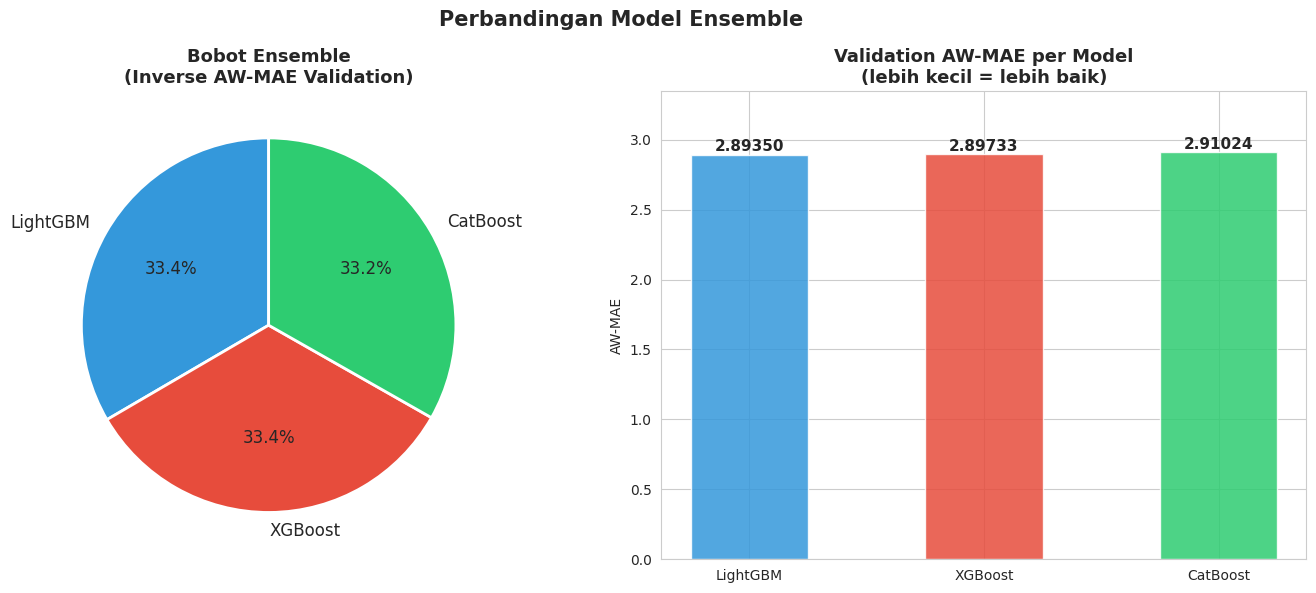

In [11]:
# VISUALISASI PERBANDINGAN MODEL DAN BOBOT ENSEMBLE

colors = ['#3498db', '#e74c3c', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart bobot
axes[0].pie(weights, labels=MODEL_NAMES, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Bobot Ensemble\n(Inverse AW-MAE Validation)', fontsize=13, fontweight='bold')

# Bar chart AW-MAE
bars = axes[1].bar(MODEL_NAMES, val_awmaes, color=colors, alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('Validation AW-MAE per Model\n(lebih kecil = lebih baik)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AW-MAE')
for bar, score in zip(bars, val_awmaes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.5f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, max(val_awmaes) * 1.15)

plt.suptitle('Perbandingan Model Ensemble', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Cell 8
## Feature Importance Ensemble

### Tujuan
Memahami fitur mana yang paling berkontribusi dalam prediksi gol, ditinjang dari model LightGBM (karena memiliki API feature importance yang paling mudah diinterpretasi).

### Interpretasi
Feature importance berbasis **gain** (rata-rata penurunan loss saat fitur digunakan sebagai split) lebih informatif dibanding berbasis count split, karena langsung mengukur kontribusi terhadap kualitas prediksi.

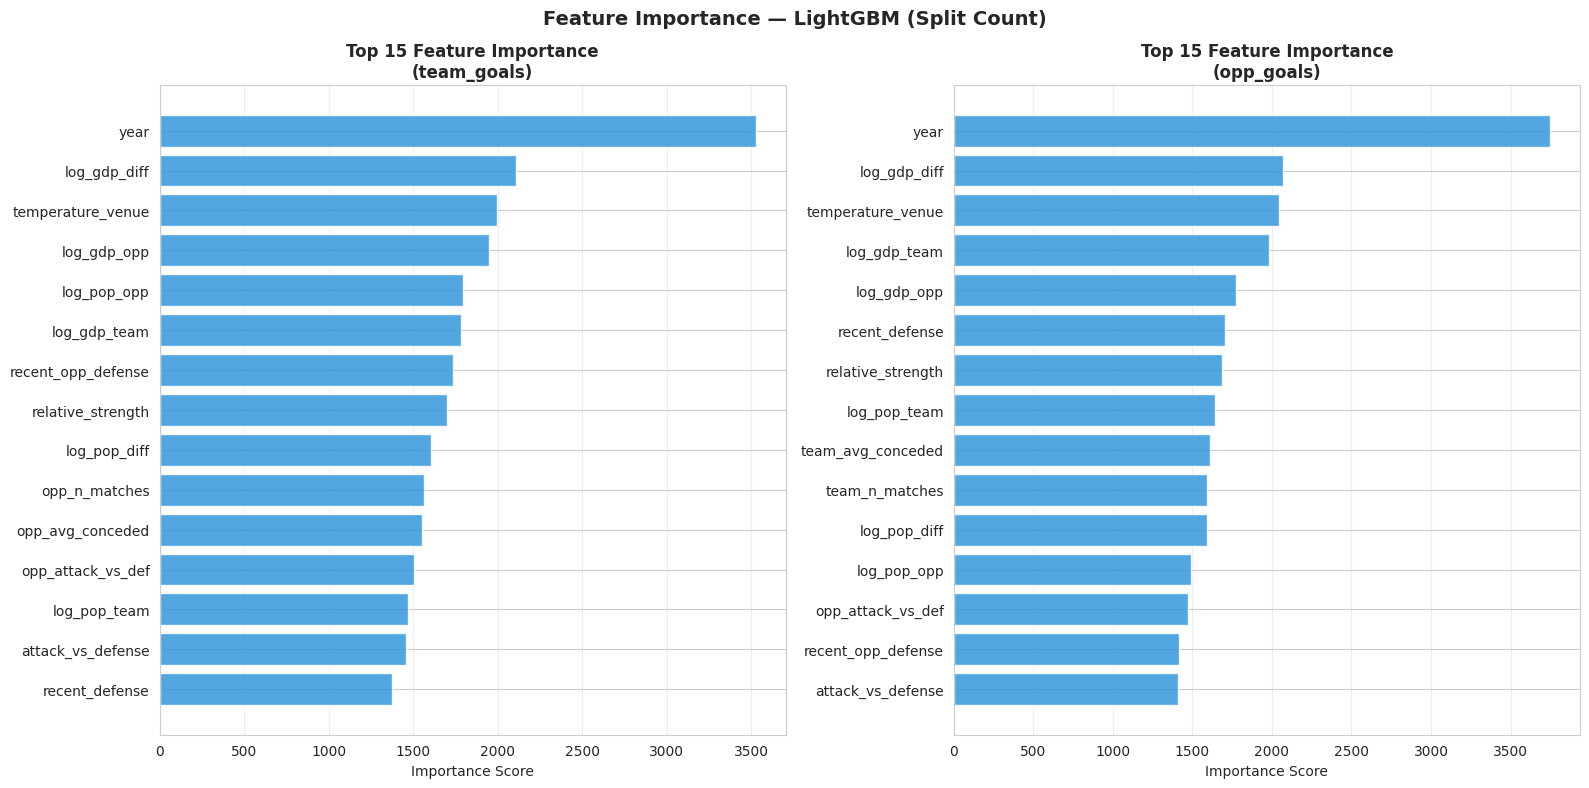

In [12]:
# VISUALISASI FEATURE IMPORTANCE (LIGHTGBM)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, model, title in zip(axes, [m_lgbm_tm, m_lgbm_op], ['team_goals', 'opp_goals']):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values().tail(15)
    bars = ax.barh(range(len(imp)), imp.values, color='#3498db', alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=10)
    ax.set_title(f'Top 15 Feature Importance\n({title})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)
plt.suptitle('Feature Importance — LightGBM (Split Count)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## Cell 9
## Prediksi Ensemble dan Consistency Post-Processing

### Strategi Ensemble
Weighted average dilakukan pada **prediksi kontinu (float)** sebelum pembulatan ke integer:

$$\\hat{y}_{\\text{final}} = w_{\\text{LGBM}} \\cdot \\hat{y}_{\\text{LGBM}} + w_{\\text{XGB}} \\cdot \\hat{y}_{\\text{XGB}} + w_{\\text{CB}} \\cdot \\hat{y}_{\\text{CB}}$$

Mengapa tidak average setelah dibulatkan? Averaging integer menyebabkan kehilangan informasi presisi, misalnya rata-rata `1` dan `2` adalah `1.5` yang kemudian dibulatkan menjadi `2`, bukan rata-rata dari `1.4` dan `1.6` yang juga menjadi `2` tetapi lebih akurat.

### Consistency Post-Processing
Setiap pertandingan memiliki **dua baris** dalam data:

| Row | team | opponent | team_goals | opp_goals |
|-----|------|----------|-----------|----------|
| A | Indonesia | Malaysia | **x** | **y** |
| B | Malaysia | Indonesia | **y** | **x** |

Tanpa post-processing, prediksi Row A dan Row B bisa tidak konsisten (x ≠ y'). Solusinya: rata-ratakan prediksi dari kedua perspektif:

```
goals_A = (predA.team + predB.opp) / 2
goals_B = (predB.team + predA.opp) / 2
```

In [13]:
# PREDIKSI ENSEMBLE — WEIGHTED AVERAGE PADA RAW PREDICTIONS

pred_team_raw = sum(w * m.predict(X_test) for w, m in zip(weights, models_team))
pred_opp_raw  = sum(w * m.predict(X_test) for w, m in zip(weights, models_opp))

print(f'pred_team range: [{pred_team_raw.min():.3f}, {pred_team_raw.max():.3f}], mean={pred_team_raw.mean():.3f}')
print(f'pred_opp  range: [{pred_opp_raw.min():.3f}, {pred_opp_raw.max():.3f}], mean={pred_opp_raw.mean():.3f}')


pred_team range: [0.070, 14.201], mean=1.510
pred_opp  range: [0.067, 14.590], mean=1.489


In [14]:
# CONSISTENCY FIX — RATA-RATAKAN PERSPEKTIF GANDA

def fix_consistency(test_df, pred_team_arr, pred_opp_arr):
    te = test_df.copy()
    te['pred_team'] = pred_team_arr
    te['pred_opp']  = pred_opp_arr
    te['match_id']  = te['Id'].str.rsplit('_', n=1).str[0]

    results = {}
    for mid, grp in te.groupby('match_id'):
        g = grp.sort_values('Id').reset_index(drop=True)
        if len(g) == 2:
            g0 = (g.iloc[0]['pred_team'] + g.iloc[1]['pred_opp']) / 2
            g1 = (g.iloc[1]['pred_team'] + g.iloc[0]['pred_opp']) / 2
            results[g.iloc[0]['Id']] = (max(0, int(round(g0))), max(0, int(round(g1))))
            results[g.iloc[1]['Id']] = (max(0, int(round(g1))), max(0, int(round(g0))))
        else:
            for _, row in g.iterrows():
                results[row['Id']] = (max(0, int(round(row['pred_team']))),
                                      max(0, int(round(row['pred_opp']))))
    return results

results = fix_consistency(test, pred_team_raw, pred_opp_raw)

sub = pd.DataFrame([{'Id': k, 'team_goals': v[0], 'opp_goals': v[1]} for k, v in results.items()])
sub = sample_sub[['Id']].merge(sub, on='Id', how='left')

# VERIFIKASI KONSISTENSI
sub2 = sub.copy(); sub2['mid'] = sub2['Id'].str.rsplit('_',n=1).str[0]
bad = sum(
    1 for _, g in sub2.groupby('mid')
    if len(g)==2 and (
        g.sort_values('Id').iloc[0].team_goals != g.sort_values('Id').iloc[1].opp_goals or
        g.sort_values('Id').iloc[0].opp_goals  != g.sort_values('Id').iloc[1].team_goals
    )
)
status = 'OK (0 inkonsistensi)' if bad == 0 else f'PERINGATAN: {bad} inkonsistensi'
print(f'Consistency check: {status}')
sub.head(10)


Consistency check: OK (0 inkonsistensi)


,Id,team_goals,opp_goals
0,M034984_Seychelles,1,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,1,1
3,M034985_Maldives,1,1
4,M034986_Réunion,1,1
5,M034986_Madagascar,1,1
6,M034987_El Salvador,1,1
7,M034987_Venezuela,1,1
8,M034988_Mayotte,1,2
9,M034988_Réunion,2,1


## Cell 10
## Analisis Distribusi Prediksi

### Tujuan
Memvalidasi bahwa distribusi prediksi ensemble masuk akal dan tidak terlalu jauh dari distribusi data training. Perbedaan yang terlalu besar bisa mengindikasikan bias sistematis dalam model.

### Visualisasi yang Dihasilkan

| Plot | Deskripsi |
|---|---|
| Distribusi gol | Perbandingan proporsi gol 0-8 antara training dan prediksi |
| Score heatmap | Skor paling sering diprediksi (team_goals × opp_goals) |

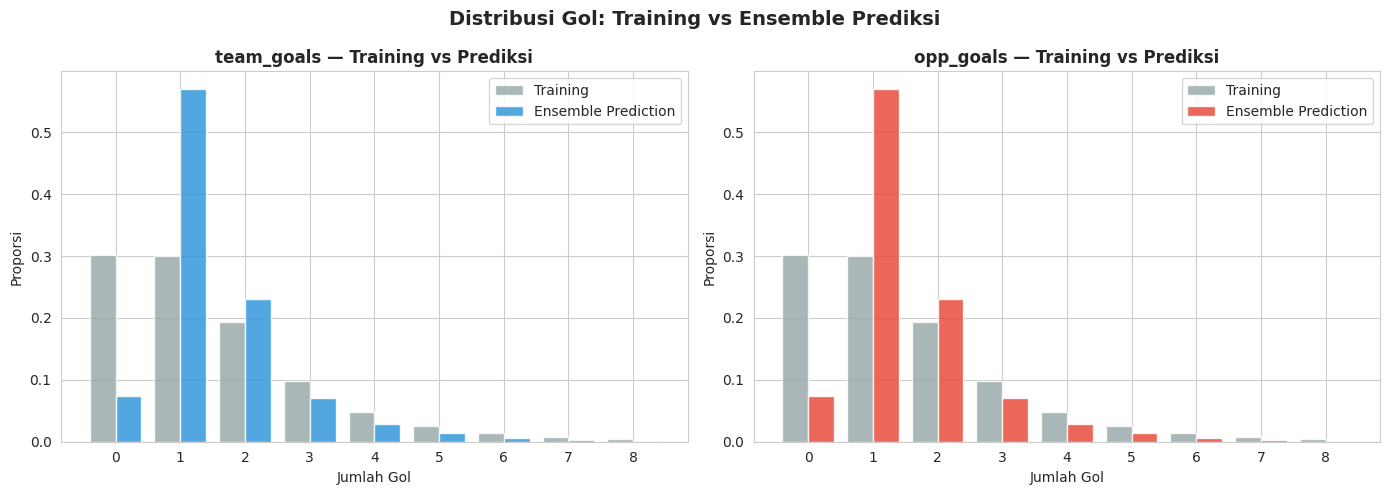

In [15]:
# DISTRIBUSI GOL: TRAINING VS ENSEMBLE PREDICTION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, c in zip(axes, ['team_goals','opp_goals'], ['#3498db','#e74c3c']):
    train_dist = train[col].value_counts().sort_index().loc[lambda x: x.index<=8] / len(train)
    pred_dist  = sub[col].value_counts().sort_index().loc[lambda x: x.index<=8] / len(sub)
    x = np.arange(9)
    ax.bar(x - 0.2, [train_dist.get(i,0) for i in range(9)], 0.4,
           label='Training', color='#95a5a6', alpha=0.8)
    ax.bar(x + 0.2, [pred_dist.get(i,0) for i in range(9)], 0.4,
           label='Ensemble Prediction', color=c, alpha=0.85)
    ax.set_title(f'{col} — Training vs Prediksi', fontsize=12, fontweight='bold')
    ax.set_xlabel('Jumlah Gol'); ax.set_ylabel('Proporsi')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.legend(fontsize=10)
plt.suptitle('Distribusi Gol: Training vs Ensemble Prediksi', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


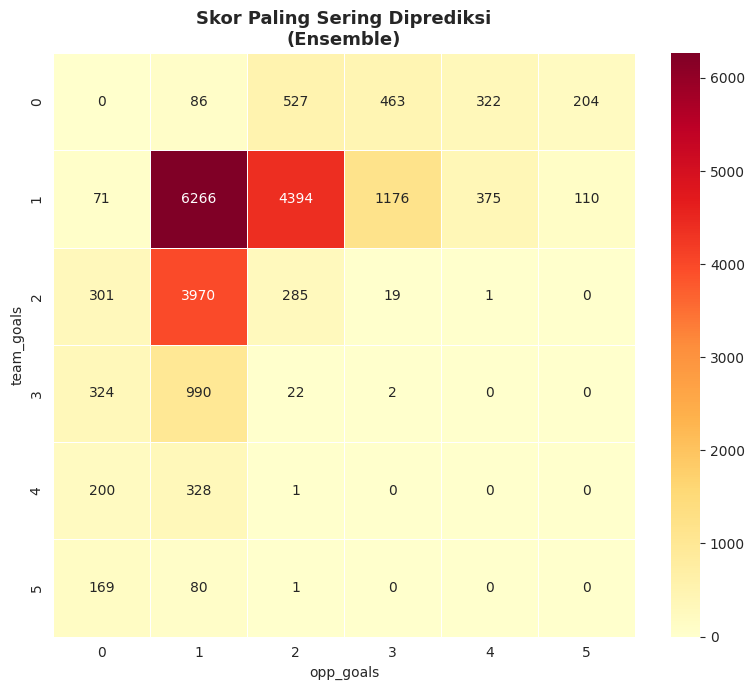

In [16]:
# SCORE HEATMAP, SKOR PALING SERING DIPREDIKSI

sub2 = sub.copy()
sub2['mid'] = sub2['Id'].str.rsplit('_',n=1).str[0]
match_scores = []
for _, g in sub2.groupby('mid'):
    if len(g)==2:
        r = g.sort_values('Id').iloc[0]
        match_scores.append({'tg': r.team_goals, 'og': r.opp_goals})
ms = pd.DataFrame(match_scores)
pivot = ms[ms.tg<=5][ms.og<=5].groupby(['tg','og']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Skor Paling Sering Diprediksi\n(Ensemble)', fontsize=13, fontweight='bold')
ax.set_xlabel('opp_goals'); ax.set_ylabel('team_goals')
plt.tight_layout(); plt.show()

sub2 = sub2.drop(columns='mid', errors='ignore')


## Cell 11
## Pembuatan File Submission Kaggle

### Format Submission
Submission mengikuti format kompetisi:

| Kolom | Deskripsi |
|---|---|
| `Id` | Identifier pertandingan per perspektif tim |
| `team_goals` | Prediksi gol tim (integer ≥ 0) |
| `opp_goals` | Prediksi gol lawan (integer ≥ 0) |

### Quality Check Sebelum Submit
Sebelum menyimpan, dilakukan pengecekan:
1. Tidak ada nilai negatif
2. Tidak ada missing value
3. ID submission sesuai dengan sample_submission
4. Konsistensi pasangan match (0 inkonsistensi)

In [17]:
# PEMBUATAN FILE SUBMISSION KAGGLE

# QUALITY CHECK
print('QUALITY CHECK SUBMISSION')
print(f'  Shape         : {sub.shape}')
print(f'  Kolom         : {sub.columns.tolist()}')
print(f'  Missing values: {sub.isnull().sum().sum()}')
print(f'  Min gol       : team={sub.team_goals.min()}, opp={sub.opp_goals.min()}')
print(f'  Max gol       : team={sub.team_goals.max()}, opp={sub.opp_goals.max()}')
print(f'  ID match      : {set(sub.Id) == set(sample_sub.Id)}')
print(f'  Consistency   : {status}')

dist_team = sub['team_goals'].value_counts().sort_index().loc[lambda x: x.index<=6].to_dict()
print(f'  Distribusi team_goals (0-6): {dist_team}')

# SIMPAN FILE
sub.to_csv('submission.csv', index=False)
print('\nsubmission.csv berhasil disimpan!')
sub.head(10)


QUALITY CHECK SUBMISSION
  Shape         : (42422, 3)
  Kolom         : ['Id', 'team_goals', 'opp_goals']
  Missing values: 0
  Min gol       : team=0, opp=0
  Max gol       : team=14, opp=14
  ID match      : True
  Consistency   : OK (0 inkonsistensi)
  Distribusi team_goals (0-6): {0: 3130, 1: 24173, 2: 9806, 3: 2998, 4: 1227, 5: 564, 6: 242}

submission.csv berhasil disimpan!


,Id,team_goals,opp_goals
0,M034984_Seychelles,1,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,1,1
3,M034985_Maldives,1,1
4,M034986_Réunion,1,1
5,M034986_Madagascar,1,1
6,M034987_El Salvador,1,1
7,M034987_Venezuela,1,1
8,M034988_Mayotte,1,2
9,M034988_Réunion,2,1


## Cell 12
## Ringkasan Pipeline dan Rekomendasi Pengembangan

### Diagram Alir Pipeline

```
DATA LOADING
    train.csv (1872–2011) + test.csv (2011–2026)
         |
FEATURE ENGINEERING (31 fitur)
    ├── Team stats    : avg goals, avg conceded, n_matches, win_rate
    ├── Recent form   : statistik 3 tahun terakhir training data
    ├── Match context : is_home, neutral, year, month, gender
    ├── Strength      : attack_vs_defense, relative_strength
    ├── Socioeconomic : log(GDP), log(populasi), selisih
    └── Geographic    : altitude, jarak perjalanan, suhu
         |
MODELING — 6 model total (2 target × 3 algoritma)
    ├── LightGBM  × 2  (objective: poisson)
    ├── XGBoost   × 2  (objective: count:poisson)
    └── CatBoost  × 2  (loss: Poisson)
         |
ENSEMBLE — Weighted Average (inverse val AW-MAE)
    → Raw continuous predictions dirata-ratakan sebelum rounding
    → Model dengan AW-MAE lebih kecil mendapat bobot lebih besar
         |
POST-PROCESSING
    ├── Consistency fix: rata-rata prediksi dari 2 perspektif
    ├── Round ke integer + clip(min=0)
    └── Verify: 0 inkonsistensi
         |
SUBMISSION = submission.csv
```